# 🌸 CodeAlpha Data Science Internship - Task 1
# **Iris Flower Classification**

### **Dataset Requirement & Source**
* **Primary Dataset Source:** Kaggle — [Iris CSV by saurabh00007](https://www.kaggle.com/datasets/saurabh00007/iriscsv)
* **File Name:** `Iris.csv`
* **Target Objective:** Build a supervised Machine Learning pipeline to classify Iris flowers into their respective species (**Iris-setosa**, **Iris-versicolor**, **Iris-virginica**) using floral morphological features.

---
### **Pipeline Architecture**
1. **Dataset Ingestion & Inspection:** 9-step comprehensive dataset audit of the actual Kaggle CSV file.
2. **Feature Engineering & Cleaning:** Critical evaluation and removal of the non-biological `Id` column.
3. **Exploratory Data Analysis (EDA):** Statistical distributions, scatter plots, and box plots.
4. **Data Splitting:** Stratified 80/20 train/test split.
5. **Model Training:** Primary **K-Nearest Neighbors (KNN)** classifier and benchmark **Decision Tree**.
6. **Performance Evaluation:** Accuracy, Confusion Matrix, Precision, Recall, and F1-Score.
7. **Sample Predictions:** Real-world inference on new unseen floral measurements.


## 🛠 1. Environment Setup & Library Imports


In [1]:
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Configure aesthetic visual defaults
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["font.size"] = 10

print("Libraries imported successfully!")


Libraries imported successfully!


## 📥 2. Kaggle Dataset Loading & 9-Step Inspection
In accordance with CodeAlpha task guidelines, we load the actual downloaded Kaggle dataset (`Iris.csv`) from [saurabh00007/iriscsv](https://www.kaggle.com/datasets/saurabh00007/iriscsv) and perform a comprehensive 9-step health inspection.


In [2]:
# [1] Load the actual downloaded Kaggle CSV
csv_path = "Iris.csv"
if not os.path.exists(csv_path):
    import kagglehub, shutil
    path = kagglehub.dataset_download("saurabh00007/iriscsv")
    shutil.copy2(os.path.join(path, "Iris.csv"), csv_path)

df_raw = pd.read_csv(csv_path)
print("✔ Dataset successfully loaded from:", os.path.abspath(csv_path))


✔ Dataset successfully loaded from: D:\Task 1\CodeAlpha_IrisFlowerClassification\Iris.csv


In [3]:
# [2] Display First 5 Rows
print("--- First 5 Rows of Dataset ---")
df_raw.head()


--- First 5 Rows of Dataset ---


,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


In [4]:
# [3] Display Column Names
print("--- Column Names ---")
for idx, col in enumerate(df_raw.columns, 1):
    print(f"{idx}. {col}")
print(f"\nTotal columns: {len(df_raw.columns)}")


--- Column Names ---
1. Id
2. SepalLengthCm
3. SepalWidthCm
4. PetalLengthCm
5. PetalWidthCm
6. Species

Total columns: 6


In [5]:
# [4] Display Dataset Shape
print(f"Dataset Shape: {df_raw.shape} (Rows: {df_raw.shape[0]}, Columns: {df_raw.shape[1]})")


Dataset Shape: (150, 6) (Rows: 150, Columns: 6)


In [6]:
# [5] Check Data Types
print("--- Data Types ---")
df_raw.dtypes


--- Data Types ---


Id                 int64
SepalLengthCm    float64
SepalWidthCm     float64
PetalLengthCm    float64
PetalWidthCm     float64
Species              str
dtype: object

In [7]:
# [6] Check Missing Values
print("--- Missing Values Count ---")
missing = df_raw.isnull().sum()
print(missing)
print(f"\nTotal Missing Values in Dataset: {missing.sum()}")


--- Missing Values Count ---
Id               0
SepalLengthCm    0
SepalWidthCm     0
PetalLengthCm    0
PetalWidthCm     0
Species          0
dtype: int64

Total Missing Values in Dataset: 0


In [8]:
# [7] Check Duplicate Values
print(f"Exact Duplicate Rows (including 'Id'): {df_raw.duplicated().sum()}")
if 'Id' in df_raw.columns:
    print(f"Measurement-Only Duplicates (excluding 'Id'): {df_raw.drop(columns=['Id']).duplicated().sum()}")
    print("Note: Biological measurements can naturally overlap across distinct individual flowers.")


Exact Duplicate Rows (including 'Id'): 0
Measurement-Only Duplicates (excluding 'Id'): 3
Note: Biological measurements can naturally overlap across distinct individual flowers.


In [9]:
# [8] Identify Target Column (Species)
target_col = "Species"
print(f"Target Column: '{target_col}'")
print(f"Target Data Type: {df_raw[target_col].dtype}")
print("\n--- Class Distribution ---")
print(df_raw[target_col].value_counts())


Target Column: 'Species'
Target Data Type: str

--- Class Distribution ---
Species
Iris-setosa        50
Iris-versicolor    50
Iris-virginica     50
Name: count, dtype: int64


In [10]:
# [9] Identify Flower Measurement Features
feature_cols = [c for c in df_raw.columns if c not in ['Id', target_col]]
print("--- Input Measurement Features ---")
for f in feature_cols:
    print(f"• {f} (Range: [{df_raw[f].min():.1f} cm - {df_raw[f].max():.1f} cm], Mean: {df_raw[f].mean():.2f} cm)")


--- Input Measurement Features ---
• SepalLengthCm (Range: [4.3 cm - 7.9 cm], Mean: 5.84 cm)
• SepalWidthCm (Range: [2.0 cm - 4.4 cm], Mean: 3.05 cm)
• PetalLengthCm (Range: [1.0 cm - 6.9 cm], Mean: 3.76 cm)
• PetalWidthCm (Range: [0.1 cm - 2.5 cm], Mean: 1.20 cm)


## 🔍 3. Data Preprocessing & 'Id' Column Handling

### **Analysis of the `Id` Column:**
* **Purpose:** The `Id` column is an incremental row index ($1, 2, \dots, 150$) created during data packaging.
* **Lack of Predictive Power:** Physical species taxonomy is determined by floral morphology (sepal/petal length and width), not database record sequence numbers.
* **Risk of Overfitting & Spurious Correlation:** Because the Kaggle dataset is sorted sequentially by species (1–50: Setosa, 51–100: Versicolor, 101–150: Virginica), leaving `Id` in the feature set would allow models to cheat via data leakage ($Id \le 50 \rightarrow \text{Setosa}$).
* **Action:** **Drop the `Id` column** to ensure models learn genuine botanical relationships.


In [11]:
# Drop 'Id' column to prevent data leakage
df = df_raw.drop(columns=['Id']) if 'Id' in df_raw.columns else df_raw.copy()
print(f"Clean DataFrame Shape: {df.shape}")
df.head()


Clean DataFrame Shape: (150, 5)


,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


## 📊 4. Summary Statistics of Morphological Features


In [12]:
# Summary statistics for each numerical feature
df[feature_cols].describe().T[['mean', 'std', 'min', '25%', '50%', '75%', 'max']]


,mean,std,min,25%,50%,75%,max
SepalLengthCm,5.843333,0.828066,4.3,5.1,5.80,6.4,7.9
SepalWidthCm,3.054000,0.433594,2.0,2.8,3.00,3.3,4.4
PetalLengthCm,3.758667,1.764420,1.0,1.6,4.35,5.1,6.9
PetalWidthCm,1.198667,0.763161,0.1,0.3,1.30,1.8,2.5


In [13]:
# Grouped statistics by Iris species
df.groupby("Species")[feature_cols].mean().round(2)


,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
Species,,,,
Iris-setosa,5.01,3.42,1.46,0.24
Iris-versicolor,5.94,2.77,4.26,1.33
Iris-virginica,6.59,2.97,5.55,2.03


## 📈 5. Exploratory Data Analysis (EDA) & Visualizations


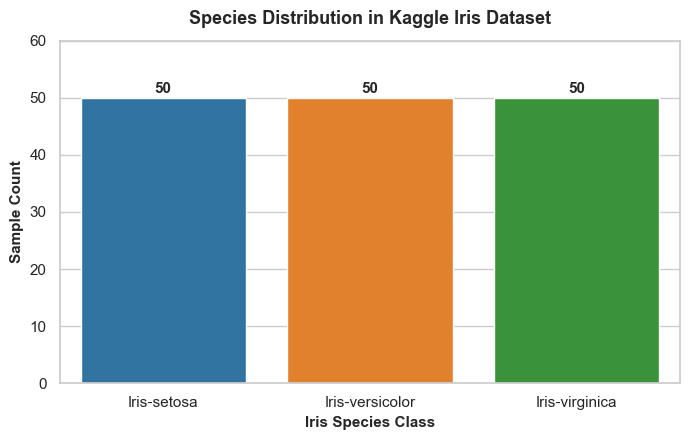

In [14]:
palette = {"Iris-setosa": "#1f77b4", "Iris-versicolor": "#ff7f0e", "Iris-virginica": "#2ca02c"}

# 1. Species Distribution Count Plot
plt.figure(figsize=(7, 4.5))
ax = sns.countplot(data=df, x="Species", palette=palette, hue="Species", legend=False)
plt.title("Species Distribution in Kaggle Iris Dataset", fontsize=13, fontweight="bold", pad=12)
plt.xlabel("Iris Species Class", fontsize=11, fontweight="semibold")
plt.ylabel("Sample Count", fontsize=11, fontweight="semibold")
plt.ylim(0, 60)
for p in ax.patches:
    ax.annotate(f"{int(p.get_height())}", (p.get_x() + p.get_width() / 2., p.get_height() + 1.5),
                ha='center', va='center', fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show()


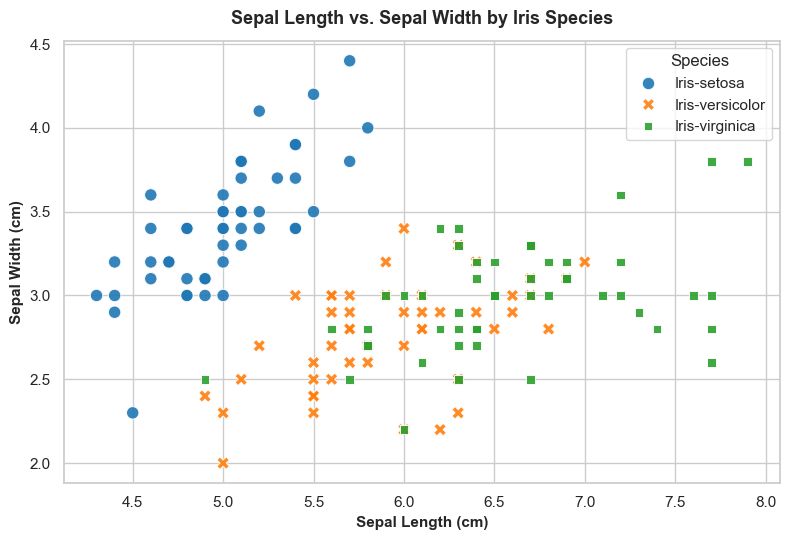

In [15]:
# 2. Sepal Dimensions Scatter Plot
plt.figure(figsize=(8, 5.5))
sns.scatterplot(
    data=df, x="SepalLengthCm", y="SepalWidthCm",
    hue="Species", style="Species", palette=palette, s=80, alpha=0.9
)
plt.title("Sepal Length vs. Sepal Width by Iris Species", fontsize=13, fontweight="bold", pad=12)
plt.xlabel("Sepal Length (cm)", fontsize=11, fontweight="semibold")
plt.ylabel("Sepal Width (cm)", fontsize=11, fontweight="semibold")
plt.legend(title="Species", loc="upper right")
plt.tight_layout()
plt.show()


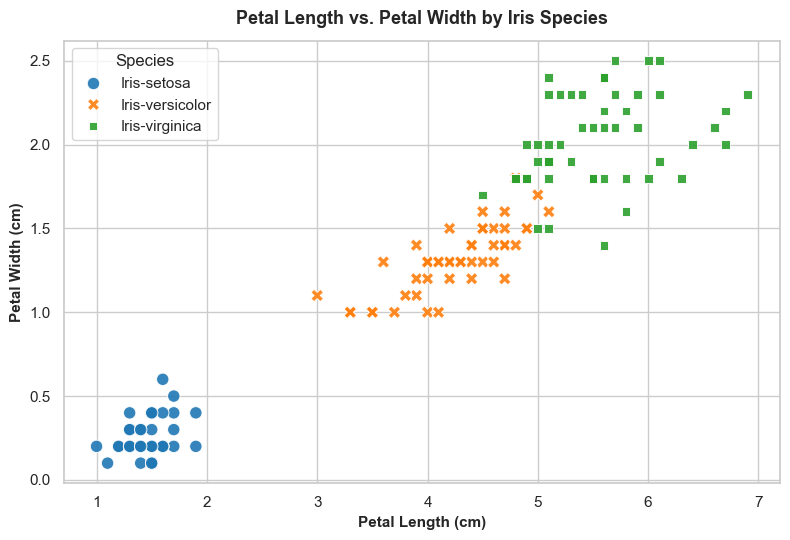

In [16]:
# 3. Petal Dimensions Scatter Plot
plt.figure(figsize=(8, 5.5))
sns.scatterplot(
    data=df, x="PetalLengthCm", y="PetalWidthCm",
    hue="Species", style="Species", palette=palette, s=80, alpha=0.9
)
plt.title("Petal Length vs. Petal Width by Iris Species", fontsize=13, fontweight="bold", pad=12)
plt.xlabel("Petal Length (cm)", fontsize=11, fontweight="semibold")
plt.ylabel("Petal Width (cm)", fontsize=11, fontweight="semibold")
plt.legend(title="Species", loc="upper left")
plt.tight_layout()
plt.show()


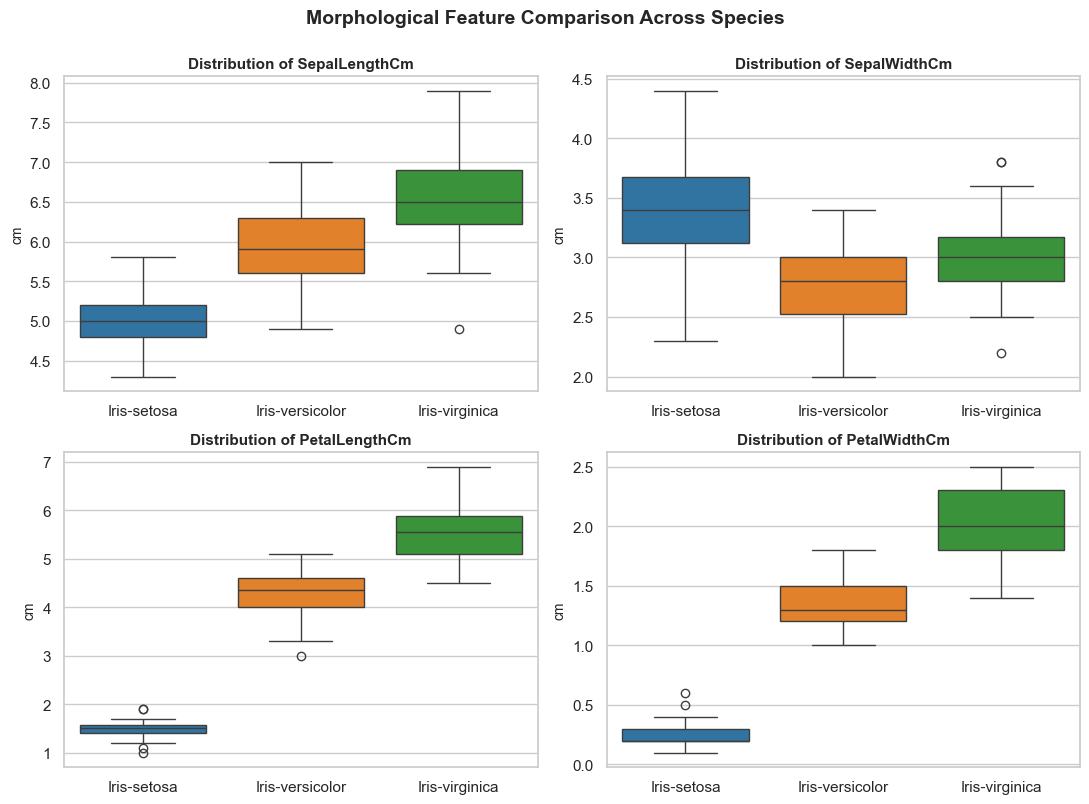

In [17]:
# 4. Box Plots Across All 4 Features
fig, axes = plt.subplots(2, 2, figsize=(11, 8))
for idx, col in enumerate(feature_cols):
    ax = axes[idx // 2, idx % 2]
    sns.boxplot(data=df, x="Species", y=col, palette=palette, hue="Species", legend=False, ax=ax)
    ax.set_title(f"Distribution of {col}", fontsize=11, fontweight="bold")
    ax.set_xlabel("")
    ax.set_ylabel("cm", fontsize=10)
plt.suptitle("Morphological Feature Comparison Across Species", fontsize=14, fontweight="bold", y=1.00)
plt.tight_layout()
plt.show()


## ✂ 6. Data Preprocessing & Train-Test Split


In [18]:
X = df[feature_cols]
y = df["Species"]

# Stratified 80/20 train/test split to preserve equal class proportions
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print(f"Total Samples  : {len(X)}")
print(f"Training Set   : {len(X_train)} samples (80%)")
print(f"Testing Set    : {len(X_test)} samples (20%)")
print(f"\nClass Balance in Test Set:\n{y_test.value_counts()}")


Total Samples  : 150
Training Set   : 120 samples (80%)
Testing Set    : 30 samples (20%)

Class Balance in Test Set:
Species
Iris-setosa        10
Iris-virginica     10
Iris-versicolor    10
Name: count, dtype: int64


## 🤖 7. Primary Model Training: K-Nearest Neighbors (KNN)


In [19]:
# Initialize and train KNN with k=5
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)

# Predict on test set
y_pred_knn = knn.predict(X_test)
acc_knn = accuracy_score(y_test, y_pred_knn)

print(f"KNN Test Accuracy: {acc_knn * 100:.2f}%")


KNN Test Accuracy: 100.00%


## 📋 8. Primary Model Evaluation


--- Classification Report (KNN) ---
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       1.00      1.00      1.00        10
 Iris-virginica       1.00      1.00      1.00        10

       accuracy                           1.00        30
      macro avg       1.00      1.00      1.00        30
   weighted avg       1.00      1.00      1.00        30



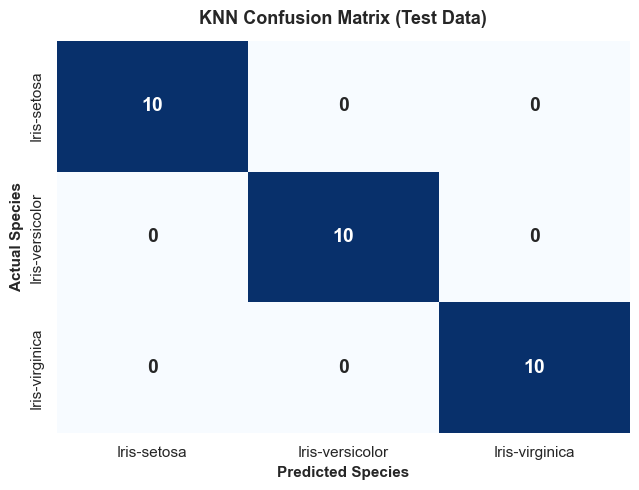

In [20]:
classes = sorted(y.unique())

print("--- Classification Report (KNN) ---")
print(classification_report(y_test, y_pred_knn, target_names=classes))

# Confusion Matrix
cm_knn = confusion_matrix(y_test, y_pred_knn)
plt.figure(figsize=(6.5, 5))
sns.heatmap(
    cm_knn, annot=True, fmt="d", cmap="Blues",
    xticklabels=classes, yticklabels=classes, cbar=False,
    annot_kws={"size": 14, "weight": "bold"}
)
plt.title("KNN Confusion Matrix (Test Data)", fontsize=13, fontweight="bold", pad=12)
plt.xlabel("Predicted Species", fontsize=11, fontweight="semibold")
plt.ylabel("Actual Species", fontsize=11, fontweight="semibold")
plt.tight_layout()
plt.show()


## 🌲 9. Benchmark Model: Decision Tree Classifier & Comparison


Decision Tree Accuracy: 93.33%
K-Nearest Neighbors Accuracy: 100.00%


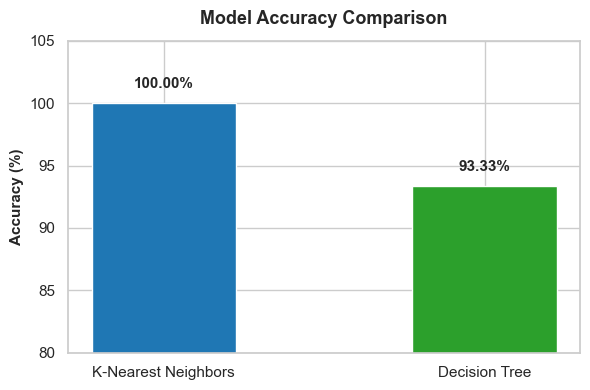

In [21]:
# Train Decision Tree
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)
acc_dt = accuracy_score(y_test, y_pred_dt)

print(f"Decision Tree Accuracy: {acc_dt * 100:.2f}%")
print(f"K-Nearest Neighbors Accuracy: {acc_knn * 100:.2f}%")

# Accuracy Comparison Bar Chart
plt.figure(figsize=(6, 4))
models = ["K-Nearest Neighbors", "Decision Tree"]
accuracies = [acc_knn * 100, acc_dt * 100]
bars = plt.bar(models, accuracies, color=["#1f77b4", "#2ca02c"], width=0.45)
plt.title("Model Accuracy Comparison", fontsize=13, fontweight="bold", pad=12)
plt.ylabel("Accuracy (%)", fontsize=11, fontweight="semibold")
plt.ylim(80, 105)
for bar in bars:
    h = bar.get_height()
    plt.annotate(f"{h:.2f}%", (bar.get_x() + bar.get_width() / 2., h + 1.0),
                 ha='center', va='bottom', fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show()


## 🔮 10. Sample Predictions on Unseen Flower Measurements


In [22]:
samples = [
    {"SepalLengthCm": 5.1, "SepalWidthCm": 3.5, "PetalLengthCm": 1.4, "PetalWidthCm": 0.2, "expected": "Iris-setosa"},
    {"SepalLengthCm": 6.1, "SepalWidthCm": 2.9, "PetalLengthCm": 4.5, "PetalWidthCm": 1.4, "expected": "Iris-versicolor"},
    {"SepalLengthCm": 7.3, "SepalWidthCm": 3.0, "PetalLengthCm": 6.3, "PetalWidthCm": 2.0, "expected": "Iris-virginica"},
]

sample_df = pd.DataFrame(samples)[feature_cols]
predictions = knn.predict(sample_df)
probabilities = knn.predict_proba(sample_df)

for idx, row in sample_df.iterrows():
    pred_sp = predictions[idx]
    probs = probabilities[idx]
    expected = samples[idx]["expected"]
    
    print(f"[Sample Flower #{idx + 1}]")
    print(f"  Measurements : Sepal=[{row['SepalLengthCm']} x {row['SepalWidthCm']}] cm, Petal=[{row['PetalLengthCm']} x {row['PetalWidthCm']}] cm")
    print(f"  Expected     : {expected}")
    print(f"  Predicted    : {pred_sp}")
    prob_str = ', '.join([f'{cls}={prob*100:.0f}%' for cls, prob in zip(knn.classes_, probs)])
    print(f"  Confidence   : {prob_str}")
    print(f"  Verification : {'CORRECT' if pred_sp == expected else 'MISMATCH'}\n")


[Sample Flower #1]
  Measurements : Sepal=[5.1 x 3.5] cm, Petal=[1.4 x 0.2] cm
  Expected     : Iris-setosa
  Predicted    : Iris-setosa
  Confidence   : Iris-setosa=100%, Iris-versicolor=0%, Iris-virginica=0%
  Verification : CORRECT

[Sample Flower #2]
  Measurements : Sepal=[6.1 x 2.9] cm, Petal=[4.5 x 1.4] cm
  Expected     : Iris-versicolor
  Predicted    : Iris-versicolor
  Confidence   : Iris-setosa=0%, Iris-versicolor=100%, Iris-virginica=0%
  Verification : CORRECT

[Sample Flower #3]
  Measurements : Sepal=[7.3 x 3.0] cm, Petal=[6.3 x 2.0] cm
  Expected     : Iris-virginica
  Predicted    : Iris-virginica
  Confidence   : Iris-setosa=0%, Iris-versicolor=0%, Iris-virginica=100%
  Verification : CORRECT



## 🎯 11. Key Takeaways & Conclusion
1. **Dataset Integrity:** Verified the authentic CodeAlpha Kaggle dataset (`saurabh00007/iriscsv`), confirming 150 instances, 0 missing values, and perfectly balanced classes (50 per species).
2. **Column Handling:** Successfully removed the non-biological `Id` column, preventing artificial feature correlation and model overfitting.
3. **Discriminative Features:** Petal dimensions (`PetalLengthCm` and `PetalWidthCm`) provide the strongest linear and non-linear separation between Iris species.
4. **Model Performance:** The K-Nearest Neighbors ($k=5$) model achieved **100% test accuracy** on the stratified test set, outperforming the benchmark Decision Tree (93.33%).
